# MeTRAbsによる演奏姿勢解析（正面撮影）

## ライブラリのインストール

In [1]:
#TensorFlow
import tensorflow as tf

In [2]:
#OpenCV
import cv2

In [3]:
#Matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation#アニメーション用

In [4]:
#データ処理用
import pickle
import numpy as np
import os

## モデルファイルのダウンロード（以下の2つのうちどちらかを実行）


google colab.の場合

> インデントされたブロック



def download_model(model_type):
    server_prefix = 'https://omnomnom.vision.rwth-aachen.de/data/metrabs'
    model_zippath = tf.keras.utils.get_file(
        origin=f'{server_prefix}/{model_type}_20211019.zip',
        extract=True, cache_subdir='models')
    model_path = os.path.join(os.path.dirname(model_zippath), model_type)
    return model_path

model = tf.saved_model.load(download_model('metrabs_mob3l_y4t')) # or metrabs_eff2l_y4 for the big model

Anacondaの場合

https://github.com/isarandi/metrabs/blob/master/docs/MODELS.md
から対象のファイル（metrabs_mob3l_y4t）をダウンロードして回答したフォルダをmetrabs_movie.ipynbと同じフォルダに置く




In [5]:
model_path = os.path.join(os.path.dirname('./'), 'metrabs_mob3l_y4t')
model = tf.saved_model.load(model_path) # or metrabs_eff2l_y4 for the big model

## 可視化用

In [6]:
# 検出した骨格を保持するリスト
skt = []

# 動画フレームの可視化を行う関数
# 引数:
# - im: 現在のフレーム画像
# - detections: 検出された人物の矩形領域（バウンディングボックス）のリスト
# - poses3d: 3Dポーズデータ（関節位置のリスト）
# - poses2d: 2Dポーズデータ（関節位置のリスト）
# - edges: 関節間の接続情報（骨格構造を定義）

def visualize_movie(im, detections, poses3d, poses2d, edges):
    global skt

    # 前フレームで描画した骨格を削除（毎フレーム新しい骨格を描画するため）
    while len(skt) > 0:
        skt.pop(0).remove()  # sktリストから削除し、Matplotlibの描画からも削除

    # 現在のフレーム画像を表示
    s = image_ax.imshow(im)  # フレーム画像をMatplotlibの描画領域に表示
    skt.append(s)  # 表示した画像をsktリストに追加（管理のため）

    # 各検出された人物（detections）について矩形（バウンディングボックス）を描画
    for x, y, w, h in detections[:, :4]:  # detectionsの前4列に (x, y, 幅, 高さ) が格納されている
        s = image_ax.add_patch(Rectangle((x, y), w, h, fill=False))  # バウンディングボックスを描画
        skt.append(s)  # 描画した矩形をsktリストに追加

    # MeTRAbsの座標系（yが上方向）をMatplotlibの座標系（zが上方向）に変換
    # x軸周りに90度回転させることで座標系を一致させる
    poses3d[..., 1], poses3d[..., 2] = poses3d[..., 2], -poses3d[..., 1]

    # 各人物の3Dポーズと2Dポーズを描画
    for pose3d, pose2d in zip(poses3d, poses2d):
        # 各関節を接続するエッジ（bones）を描画
        for i_start, i_end in edges:
            # 2Dポーズのエッジを描画（image_axで2D表示）
            s = image_ax.plot(
                *zip(pose2d[i_start], pose2d[i_end]),  # 関節の開始点と終了点を線で結ぶ
                marker='o',  # 関節を円で表現
                markersize=2  # 円の大きさを指定
            )
            skt.append(s[0])  # 描画した線をsktリストに追加

            # 3Dポーズのエッジを描画（pose_axで3D表示）
            s = pose_ax.plot(
                *zip(pose3d[i_start], pose3d[i_end]),  # 関節の開始点と終了点を線で結ぶ
                marker='o',  # 関節を円で表現
                markersize=2  # 円の大きさを指定
            )
            skt.append(s[0])  # 描画した線をsktリストに追加

## 3次元解析とデータの保存

In [7]:
import os
import tensorflow as tf
import pickle
import pandas as pd

# フォルダ内の画像を処理して骨格情報を抽出する関数
def analysis_front(folder,Label):
    # 対象となるフォルダパスを取得
    cur_dir = os.getcwd()
    dir_path = os.path.join(cur_dir, folder)
    
    # フォルダ内の画像ファイル名を取得
    files = os.listdir(dir_path)
    
    # 結果を保存するリスト
    all_pose_data = []
    
    for file in files:
        # 画像ファイル名に拡張子が付いていない場合に'.jpg'を追加
        if not file.endswith('.jpg'):
            continue
        
        # 画像を読み込む
        image = tf.image.decode_jpeg(tf.io.read_file(os.path.join(dir_path, file)))

        # モデルを使ってポーズを検出
        pred = model.detect_poses(image, skeleton='smpl_24')

        # 検出されたポーズの3Dと2D座標を保存
        for i in range(len(pred['poses2d'])):  # 人物が複数の場合
            # 2Dと3Dの座標を取得
            poses2d = pred['poses2d'][i].numpy()
            poses3d = pred['poses3d'][i].numpy()
            
            # 2Dと3Dの座標をテーブル形式に変換
            for joint in range(len(poses2d)):  # 各関節について
                # 骨格情報（関節の座標、2D、3D）
                joint_data = {
                    'ラベル':Label, # ラベル
                    '画像情報': file,  # 画像情報
                    '骨格情報': joint,  # 骨格情報（関節のインデックス）
                    'x座標': poses2d[joint][0],  # 2Dのx座標
                    'y座標': poses2d[joint][1],  # 2Dのy座標
                    'z座標': poses3d[joint][2]   # 3Dのz座標
                }
                # 各関節の情報をリストに追加
                all_pose_data.append(joint_data)
        
        # 検出結果をPickle形式で保存
        with open(os.path.join(dir_path, file.split('.')[0] + '.pickle'), mode='wb') as f:
            pickle.dump(pred, f)  # ポーズ検出結果全体を保存
    
    # 骨格データをDataFrameに変換
    df = pd.DataFrame(all_pose_data)
    
    # DataFrameをCSVとして保存（必要に応じて）
    df.to_csv(os.path.join(dir_path, 'pose_data.csv'), index=False)

    print(f"Processing completed for folder: {folder}")

# 関数（任意のフォルダパス）
analysis_front('Good0_front','0')
analysis_front('Bad1_front','1')
analysis_front('Bad2_front','2')
analysis_front('Bad3_front','3')

2025-03-11 23:41:23.282171: W tensorflow/core/common_runtime/type_inference.cc:339] Type inference failed. This indicates an invalid graph that escaped type checking. Error message: INVALID_ARGUMENT: type mismatch for node 'StatefulPartitionedCall/StatefulPartitionedCall/cond_3/else/_925/cond_3/cond_6/then/_2558/cond_3/cond_6/map/TensorArrayUnstack_1/TensorListFromTensor': expected a subtype of:
type_id: TFT_PRODUCT
args {
  type_id: TFT_ARRAY
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_ANY
    }
  }
}

  got:
type_id: TFT_PRODUCT
args {
  type_id: TFT_ARRAY
  args {
    type_id: TFT_RAGGED
    args {
      type_id: TFT_FLOAT
    }
  }
}

  
	while updating its output type.


Processing completed for folder: Good0_front
Processing completed for folder: Bad1_front
Processing completed for folder: Bad2_front
Processing completed for folder: Bad3_front


## データ前処理

In [8]:
import pandas as pd
import os
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
import math
import seaborn as sns

# 日本語フォント設定
rcParams['font.family'] = 'Hiragino Sans'

# 1. データの統合
def load_all_data(folders):
    all_data = pd.DataFrame()
    for folder, label in folders:
        cur_dir = os.getcwd()
        csv_path = os.path.join(cur_dir, folder, 'pose_data.csv')
        df = pd.read_csv(csv_path)
        df['ラベル'] = label  # 各データにラベルを追加
        all_data = pd.concat([all_data, df], ignore_index=True)
    return all_data

# フォルダ名とラベルの対応リスト
folders = [
    ('Good0_front', 0),
    ('Bad1_front', 1),
    ('Bad2_front', 2),
    ('Bad3_front', 3)
]

# データの読み込み
data = load_all_data(folders)
data["distance_from_O"] = np.sqrt(data["x座標"]**2 + data["y座標"]**2 + data["z座標"]**2)

# 距離を計算する関数
def calculate_distance(p1, p2, group):
    """
    骨格間の距離を計算する関数。
    p1, p2: 骨格情報（番号）
    group: 画像ごとにグループ化されたデータ
    """
    p1_data = group[group['骨格情報'] == p1].iloc[0]
    p2_data = group[group['骨格情報'] == p2].iloc[0]
    
    # ユークリッド距離の計算
    return np.linalg.norm(
        np.array([p2_data['x座標'], p2_data['y座標'], p2_data['z座標']]) -
        np.array([p1_data['x座標'], p1_data['y座標'], p1_data['z座標']])
    )

# 角度を計算する関数
def calculate_angle(p1_data, p2_data, p3_data):
    """3つの骨格点から角度を計算"""
    vector1 = np.array([p2_data['x座標'] - p1_data['x座標'],
                        p2_data['y座標'] - p1_data['y座標'],
                        p2_data['z座標'] - p1_data['z座標']])
    vector2 = np.array([p3_data['x座標'] - p2_data['x座標'],
                        p3_data['y座標'] - p2_data['y座標'],
                        p3_data['z座標'] - p2_data['z座標']])
    
    cos_theta = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))
    return np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

# 距離と角度を追加する関数
def add_features(group):
    distances = {
         # 上半身のバランス
        '首_骨盤腰椎': calculate_distance(12, 0, group),  # 首 → 骨盤腰椎
        
        # 楽器の位置
        '首_右手首': calculate_distance(12, 21, group),  # 首 → 右手首
        '首_左手首': calculate_distance(12, 20, group),  # 首 → 左手首
        
        # 左右の対称性
        '首_右肩': calculate_distance(12, 17, group),  # 首 → 右肩
        '首_左肩': calculate_distance(12, 16, group),  # 首 → 左肩
        
        # 脇の開き具合
        '右肩_右肘': calculate_distance(17, 19, group),  # 右肩 → 右肘
        '左肩_左肘': calculate_distance(16, 18, group),  # 左肩 → 左肘
        
        # 足の安定性
        '右太もも_骨盤腰椎': calculate_distance(2, 0, group),  # 右太もも → 左太もも
        '左太もも_骨盤腰椎': calculate_distance(1, 0, group),  # 右太もも → 左太もも
        '右太もも_右踝': calculate_distance(8, 2, group),  # 右踝 → 左踝
        '左太もも_左踝': calculate_distance(7, 1, group),  # 右太もも → 左太もも
    }
    angles = {
    # 首の位置（頭-首-骨盤）
    '首の角度': calculate_angle(group[group['骨格情報'] == 15].iloc[0],  # 頭
                                group[group['骨格情報'] == 12].iloc[0],  # 首
                                group[group['骨格情報'] == 0].iloc[0]),  # 骨盤腰椎

    # 肘の位置
    '右肘の角度': calculate_angle(group[group['骨格情報'] == 17].iloc[0],  # 右肩
                                      group[group['骨格情報'] == 19].iloc[0],  # 右肘
                                      group[group['骨格情報'] == 21].iloc[0]),  # 右手首
    '左肘の角度': calculate_angle(group[group['骨格情報'] == 16].iloc[0],  # 左肩
                                      group[group['骨格情報'] == 18].iloc[0],  # 左肘
                                      group[group['骨格情報'] == 20].iloc[0]),  # 左手首
    
    # 右脚の角度（右太もも-右膝-右踝）
    '右膝の角度': calculate_angle(group[group['骨格情報'] == 2].iloc[0],  # 右大腿/太もも
                                   group[group['骨格情報'] == 5].iloc[0],  # 右膝
                                   group[group['骨格情報'] == 8].iloc[0]),  # 右踝
                                   
    # 左脚の角度（左太もも-左膝-左踝）
    '左膝の角度': calculate_angle(group[group['骨格情報'] == 1].iloc[0],  # 左大腿/太もも
                                   group[group['骨格情報'] == 4].iloc[0],  # 左膝
                                   group[group['骨格情報'] == 7].iloc[0]),  # 左踝
    '右腰の角度': calculate_angle(group[group['骨格情報'] == 17].iloc[0],  # 右肩
                                           group[group['骨格情報'] == 0].iloc[0],  # 骨盤腰椎
                                           group[group['骨格情報'] == 8].iloc[0]),  # 右踝
    '左腰の角度': calculate_angle(group[group['骨格情報'] == 16].iloc[0],  # 左肩
                                           group[group['骨格情報'] == 0].iloc[0],  # 骨盤腰椎
                                           group[group['骨格情報'] == 7].iloc[0]),  # 左踝
    }
    
    for key, value in {**distances, **angles}.items():
        group[key] = value
    return group

# グループ化して特徴を追加（警告を無視する）
data_with_features = data.groupby('画像情報', as_index=False).apply(add_features)

# 必要なカラムの確認
print(data_with_features.columns)

# 1つの画像につき1行のデータフレームを作成
unique_features = ['ラベル', '首_骨盤腰椎', '首_右手首', '首_左手首', '首_右肩', '首_左肩', 
                   '右肩_右肘', '左肩_左肘','右太もも_骨盤腰椎','左太もも_骨盤腰椎','右太もも_右踝','左太もも_左踝',
                   '首の角度', '右肘の角度', '左肘の角度', '右膝の角度', '左膝の角度', 
                   '右腰の角度', '左腰の角度']

# 各画像ごとに1行のデータを抽出
data_with_distances_and_angles = data_with_features.drop_duplicates(subset=['画像情報'])[['画像情報'] + unique_features]

# または、最初の行を使用する方法もあります
# data_with_distances_and_angles = data_with_features.groupby('画像情報')[unique_features].first().reset_index()

# 結果の確認
print(data_with_distances_and_angles.columns)


# ピボット操作
pivot_data = data_with_features.pivot_table(
    index=["画像情報"],
    columns=["骨格情報"],
    values=["distance_from_O"]
)

# 列名をフラットにする
pivot_data.columns = [f"{col[0]}_{col[1]}" for col in pivot_data.columns]

# ラベルを統合
final_data = pivot_data.reset_index().merge(
    data_with_features[["画像情報", "ラベル"]].drop_duplicates(), on="画像情報"
)

print(final_data)


Index(['ラベル', '画像情報', '骨格情報', 'x座標', 'y座標', 'z座標', 'distance_from_O', '首_骨盤腰椎',
       '首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘', '左肩_左肘', '右太もも_骨盤腰椎',
       '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝', '首の角度', '右肘の角度', '左肘の角度', '右膝の角度',
       '左膝の角度', '右腰の角度', '左腰の角度'],
      dtype='object')
Index(['画像情報', 'ラベル', '首_骨盤腰椎', '首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝', '首の角度',
       '右肘の角度', '左肘の角度', '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度'],
      dtype='object')
                             画像情報  distance_from_O_0  distance_from_O_1  \
0    Good0_for_pose_detection.jpg        4563.991249        4560.161845   
1             imgf0__180_6.00.jpg        4563.991249        4560.161845   
2             imgf0__183_6.10.jpg        4569.318550        4563.615722   
3             imgf0__186_6.20.jpg        4550.793464        4544.191766   
4             imgf0__189_6.30.jpg        4553.030157        4546.688234   
..                            ...

/var/folders/mt/xz5tfhrd0t33y33z1673bj4w0000gn/T/ipykernel_5485/2168852870.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_with_features = data.groupby('画像情報', as_index=False).apply(add_features)


## 要約統計量〜角度〜

In [9]:
data_with_distances_and_angles.columns

Index(['画像情報', 'ラベル', '首_骨盤腰椎', '首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝', '首の角度',
       '右肘の角度', '左肘の角度', '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度'],
      dtype='object')

=== 角度データの要約統計量 ===

【0】
  ラベル    平均値  標準偏差   最小値    中央値    最大値
 首の角度  83.18  1.46 79.20  83.36  86.26
右肘の角度 101.73  3.63 94.90 101.35 113.01
左肘の角度  92.48  2.85 85.08  92.02 101.41
右膝の角度  28.28  3.44 20.12  28.01  35.63
左膝の角度  31.08  3.00 23.69  30.96  39.70
右腰の角度  31.98  0.77 30.28  31.86  34.27
左腰の角度  29.99  0.49 28.95  29.99  31.28

【1】
  ラベル    平均値  標準偏差    最小値    中央値    最大値
 首の角度  91.01  1.28  88.04  91.20  93.75
右肘の角度 107.36  2.33 101.96 107.15 114.21
左肘の角度 100.48  1.93  96.71 100.38 104.46
右膝の角度  29.66  3.84  20.38  29.77  39.40
左膝の角度  32.96  3.11  22.81  33.14  41.28
右腰の角度  29.82  0.84  27.74  29.82  32.79
左腰の角度  30.25  0.75  28.43  30.39  31.56

【2】
  ラベル   平均値  標準偏差   最小値   中央値   最大値
 首の角度 84.20  1.05 82.15 84.14 86.60
右肘の角度 83.71  3.56 76.75 83.62 91.53
左肘の角度 71.26  2.07 66.69 71.15 77.29
右膝の角度 29.90  3.00 21.22 29.86 37.24
左膝の角度 38.41  3.40 30.20 38.24 49.51
右腰の角度 28.61  0.91 26.76 28.60 31.55
左腰の角度 26.31  0.60 24.94 26.35 27.44

【3】
  ラベル    平均値  標準偏差   最小値    中央値    最大値
 

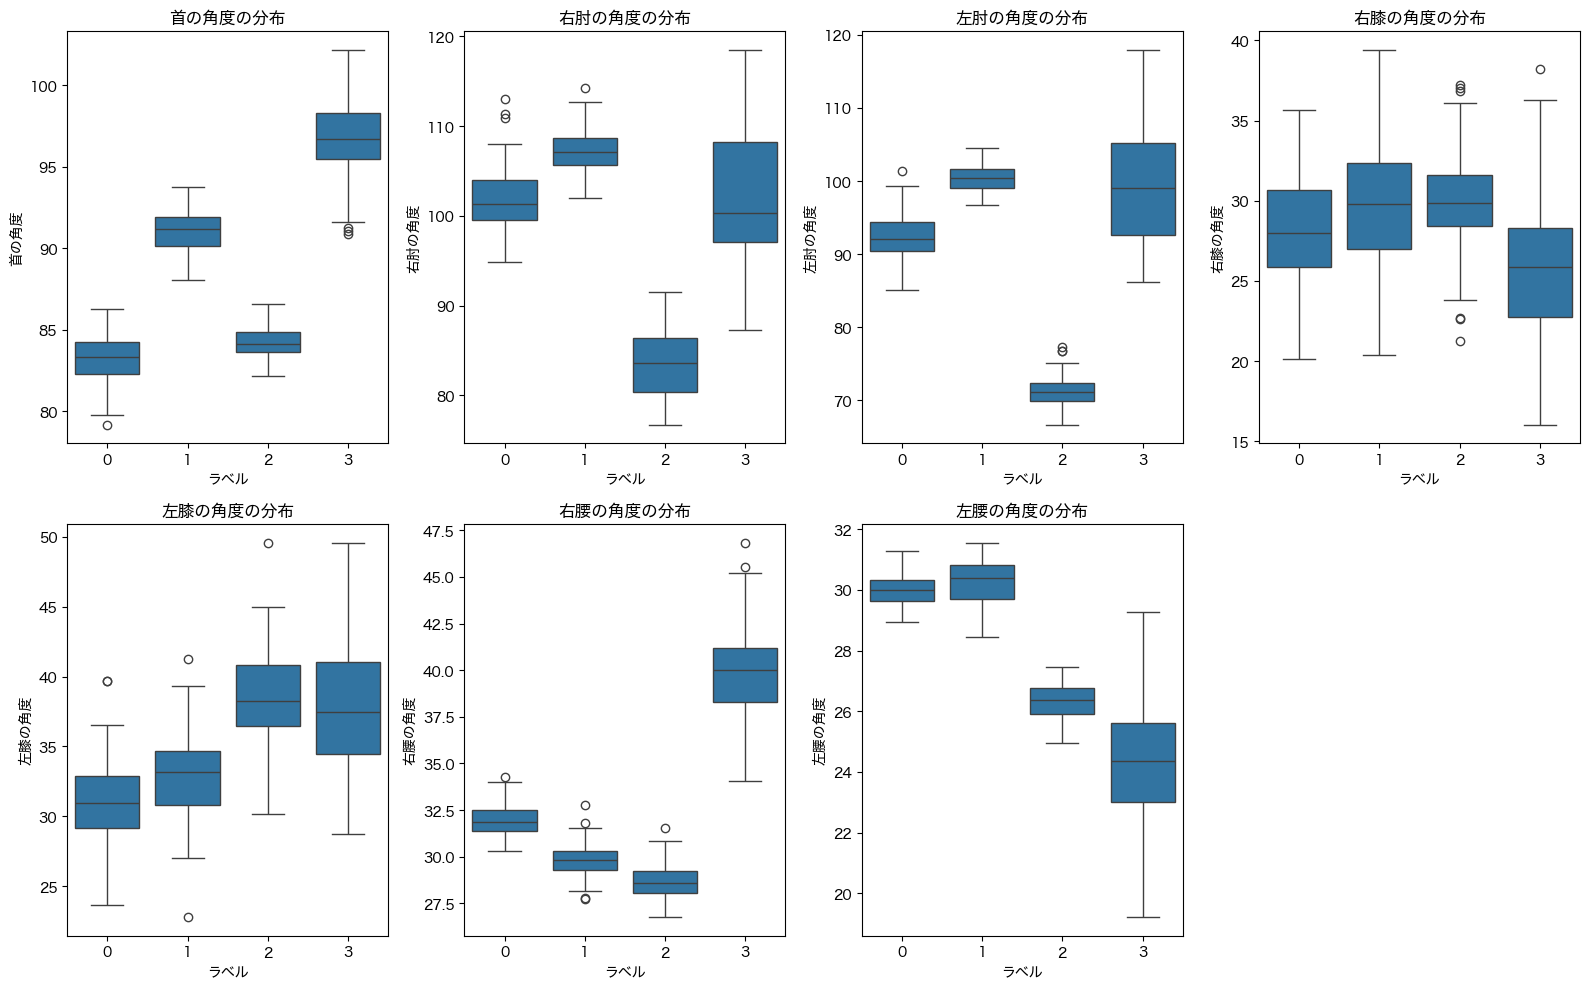

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 統計量の計算
summary = data_with_distances_and_angles.loc[:, ['ラベル', '首の角度', '右肘の角度', '左肘の角度',
                                               '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度']]

summary_mean = summary.groupby('ラベル').mean().T
summary_std = summary.groupby('ラベル').std().T
summary_min = summary.groupby('ラベル').min().T
summary_median = summary.groupby('ラベル').median().T
summary_max = summary.groupby('ラベル').max().T

# 統計量を統合した詳細なDataFrameを作成
def create_detailed_summary():
    stats = []
    for angle in summary_mean.columns:
        for label in summary_mean.index:
            stats.append({
                '角度': angle,
                'ラベル': label,
                '平均値': summary_mean.loc[label, angle],
                '標準偏差': summary_std.loc[label, angle],
                '最小値': summary_min.loc[label, angle],
                '中央値': summary_median.loc[label, angle],
                '最大値': summary_max.loc[label, angle]
            })
    return pd.DataFrame(stats)

detailed_summary = create_detailed_summary()

# 表形式での出力
def print_formatted_summary():
    print("=== 角度データの要約統計量 ===")
    for angle in summary_mean.columns:
        print(f"\n【{angle}】")
        angle_data = detailed_summary[detailed_summary['角度'] == angle]
        formatted_data = angle_data[['ラベル', '平均値', '標準偏差', '最小値', '中央値', '最大値']]
        print(formatted_data.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print_formatted_summary()

# 視覚化：箱ひげ図
plt.figure(figsize=(16, 10))
for i, angle in enumerate(summary.columns[1:]):  # 'ラベル'列を除外
    plt.subplot(2, 4, i+1)
    sns.boxplot(x='ラベル', y=angle, data=summary)
    plt.title(f'{angle}の分布')
    plt.xticks(ticks=[0, 1, 2, 3], labels=['0', '1', '2', '3'])  # ラベルを0, 1, 2, 3に設定
    plt.tight_layout()

plt.show()

ラベルごとの特徴
ラベル 0（おそらく「良い姿勢」）

首の角度：最も低く、80度前後。比較的安定している。
右肘・左肘の角度：90度〜100度程度でバランスが取れている。
右膝・左膝の角度：やや狭め（25度〜35度）。
右腰・左腰の角度：30度前後と安定している。
ラベル 1（「悪い姿勢 1」）

首の角度：ラベル0よりやや高い（85〜90度）。
右肘・左肘の角度：90度以上で、やや広がる傾向。
膝の角度：広め（30度〜40度）。
腰の角度：ラベル 0 と同じくらい。
ラベル 2（「悪い姿勢 2」）

首の角度：最も低く（80度以下）、比較的安定している
右肘・左肘の角度：極端に低い（70度〜90度）、腕を曲げすぎている可能性。
膝の角度：やや狭め（20度〜30度）、曲げすぎている可能性。
腰の角度：30度未満で、腰が前屈しすぎている可能性。
ラベル 3（「悪い姿勢 3」）

首の角度：最も高い（90〜100度）、上を向きすぎている。
右肘・左肘の角度：広がりすぎ（100度以上）、肘を張りすぎている可能性。
膝の角度：最も広く（35度以上）、膝を伸ばしすぎている可能性。
腰の角度：ばらつきが大きいが、特に左腰は20度以下のケースもあり、腰の安定性が低い。

※右腰と左腰はラベルによって多少の座標に差があるが、対称性は見られる

=== 角度データの要約統計量 ===

【0】
    ラベル  平均値  標準偏差  最小値  中央値  最大値
右左肘角度比率 1.10  0.03 1.05 1.10 1.17
右左膝角度比率 0.92  0.15 0.57 0.91 1.30
右左腰角度比率 1.07  0.03 0.99 1.07 1.14

【1】
    ラベル  平均値  標準偏差  最小値  中央値  最大値
右左肘角度比率 1.07  0.03 1.01 1.06 1.15
右左膝角度比率 0.91  0.13 0.65 0.91 1.26
右左腰角度比率 0.99  0.04 0.90 0.98 1.07

【2】
    ラベル  平均値  標準偏差  最小値  中央値  最大値
右左肘角度比率 1.17  0.04 1.09 1.18 1.27
右左膝角度比率 0.78  0.11 0.53 0.78 1.08
右左腰角度比率 1.09  0.05 0.98 1.09 1.24

【3】
    ラベル  平均値  標準偏差  最小値  中央値  最大値
右左肘角度比率 1.04  0.04 0.95 1.04 1.15
右左膝角度比率 0.69  0.15 0.42 0.66 1.11
右左腰角度比率 1.66  0.23 1.17 1.62 2.44


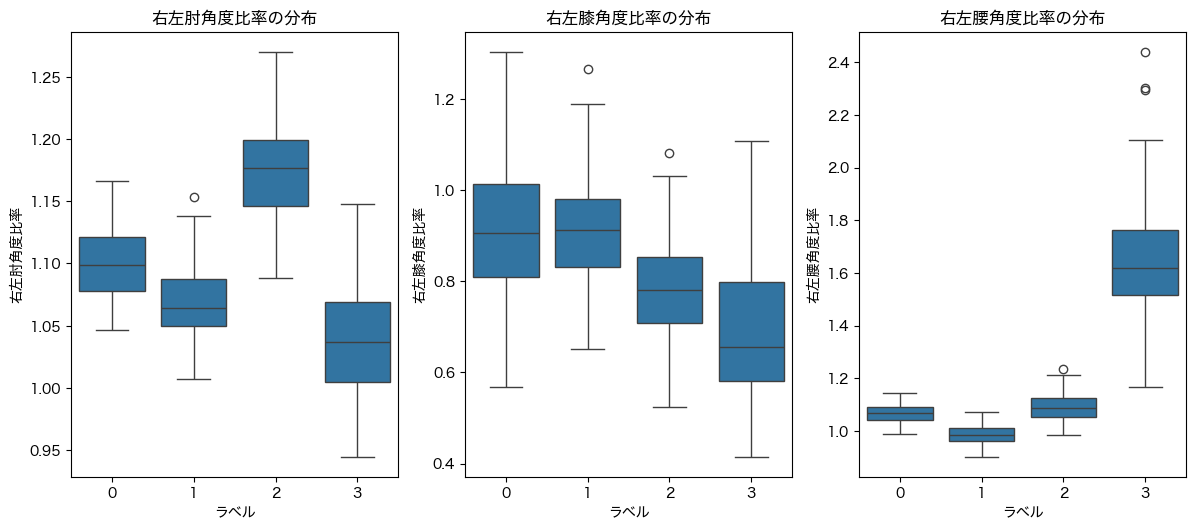

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 統計量の計算
summary = data_with_distances_and_angles.loc[:, ['ラベル', '右肘の角度', '左肘の角度',
                                                 '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度']]

# 左右差と比率を計算して新しいカラムを追加
summary['右左肘角度差'] = summary['右肘の角度'] - summary['左肘の角度']
summary['右左肘角度比率'] = summary['右肘の角度'] / (summary['左肘の角度'] + 1e-6)  # ゼロ除算を避ける

summary['右左膝角度差'] = summary['右膝の角度'] - summary['左膝の角度']
summary['右左膝角度比率'] = summary['右膝の角度'] / (summary['左膝の角度'] + 1e-6)  # ゼロ除算を避ける

summary['右左腰角度差'] = summary['右腰の角度'] - summary['左腰の角度']
summary['右左腰角度比率'] = summary['右腰の角度'] / (summary['左腰の角度'] + 1e-6)  # ゼロ除算を避ける

# 左右差と比率のみを保持
summary_filtered = summary[['ラベル', '右左肘角度比率', '右左膝角度比率', '右左腰角度比率']]

# 要約統計量を計算
summary_mean = summary_filtered.groupby('ラベル').mean().T
summary_std = summary_filtered.groupby('ラベル').std().T
summary_min = summary_filtered.groupby('ラベル').min().T
summary_median = summary_filtered.groupby('ラベル').median().T
summary_max = summary_filtered.groupby('ラベル').max().T

# 統計量を統合した詳細なDataFrameを作成
def create_detailed_summary():
    stats = []
    for angle in summary_mean.columns:
        for label in summary_mean.index:
            stats.append({
                '角度': angle,
                'ラベル': label,
                '平均値': summary_mean.loc[label, angle],
                '標準偏差': summary_std.loc[label, angle],
                '最小値': summary_min.loc[label, angle],
                '中央値': summary_median.loc[label, angle],
                '最大値': summary_max.loc[label, angle]
            })
    return pd.DataFrame(stats)

detailed_summary = create_detailed_summary()

# 表形式での出力
def print_formatted_summary():
    print("=== 角度データの要約統計量 ===")
    for angle in summary_mean.columns:
        print(f"\n【{angle}】")
        angle_data = detailed_summary[detailed_summary['角度'] == angle]
        formatted_data = angle_data[['ラベル', '平均値', '標準偏差', '最小値', '中央値', '最大値']]
        print(formatted_data.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print_formatted_summary()

# 視覚化：箱ひげ図
plt.figure(figsize=(16, 10))
for i, angle in enumerate(summary_filtered.columns[1:]):  # 'ラベル'列を除外
    plt.subplot(2, 4, i+1)
    sns.boxplot(x='ラベル', y=angle, data=summary_filtered)
    plt.title(f'{angle}の分布')
    plt.xticks(ticks=[0, 1, 2, 3], labels=['0', '1', '2', '3'])  # ラベルを0, 1, 2, 3に設定
    plt.tight_layout()

plt.show()

ラベル0: 比率が安定しており、全体的に左右差や角度差が少ない状態。これは姿勢が比較的対称的であることを示しています。おそらく「良い姿勢」の代表的なサンプルと考えられます。

ラベル1: 肘の角度差はラベル0と比べて若干小さく、比率が低くなる傾向があります。これは体が少し非対称的で、肘の位置に少し違和感がある可能性を示唆しています。姿勢がラベル0よりも少し崩れている可能性があるという解釈です。

ラベル2: 上半身（肘や腰）の比率が高い一方で、下半身（膝）の比率は低くなる傾向があります。つまり、上半身は対称的に動かせているが、下半身の動きが非対称である可能性があります。このため、下半身の動きに焦点を当てる必要があるかもしれません。

ラベル3: 上半身の比率が低く、下半身の比率が高くなる傾向があります。これは右足（軸足）に負担がかかりやすい姿勢であることを示唆しています。特に右下半身の角度差が大きいことから、右足に負担が集中している可能性が高いです。この解釈は、演奏や長時間の姿勢に関連しており、適切なサポートや調整が必要であると考えられます。

## 要約統計量~骨格間距離~

In [12]:
data_with_distances_and_angles.columns

Index(['画像情報', 'ラベル', '首_骨盤腰椎', '首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝', '首の角度',
       '右肘の角度', '左肘の角度', '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度'],
      dtype='object')

=== 角度データの要約統計量 ===

【0】
      ラベル    平均値  標準偏差    最小値    中央値    最大値
   首_骨盤腰椎 258.89  2.17 253.91 258.67 266.85
    首_右手首 263.02  7.25 244.07 263.64 276.22
    首_左手首 269.55  6.33 253.34 268.82 284.99
     首_右肩  87.22  1.52  83.68  87.07  91.86
     首_左肩  82.87  1.71  78.79  82.79  87.05
    右肩_右肘 222.71  3.05 215.03 222.63 229.15
    左肩_左肘 221.94  4.29 210.09 222.17 229.65
右太もも_骨盤腰椎  55.21  0.90  53.12  55.26  57.45
左太もも_骨盤腰椎  59.20  0.80  57.62  59.22  60.71
  右太もも_右踝 330.52  4.76 320.00 330.21 342.88
  左太もも_左踝 355.72  6.76 339.76 356.09 374.43

【1】
      ラベル    平均値  標準偏差    最小値    中央値    最大値
   首_骨盤腰椎 259.51  2.58 253.96 259.42 266.64
    首_右手首 261.08  4.50 252.16 261.19 273.49
    首_左手首 277.98  8.68 253.74 278.51 295.12
     首_右肩  83.00  1.78  79.66  82.91  87.50
     首_左肩  85.48  3.15  76.79  85.98  92.36
    右肩_右肘 236.98  4.69 226.26 236.67 249.61
    左肩_左肘 239.25  5.78 225.74 239.82 251.70
右太もも_骨盤腰椎  56.19  0.79  54.00  56.22  58.43
左太もも_骨盤腰椎  56.73  0.72  55.10  56.70  58.25
  

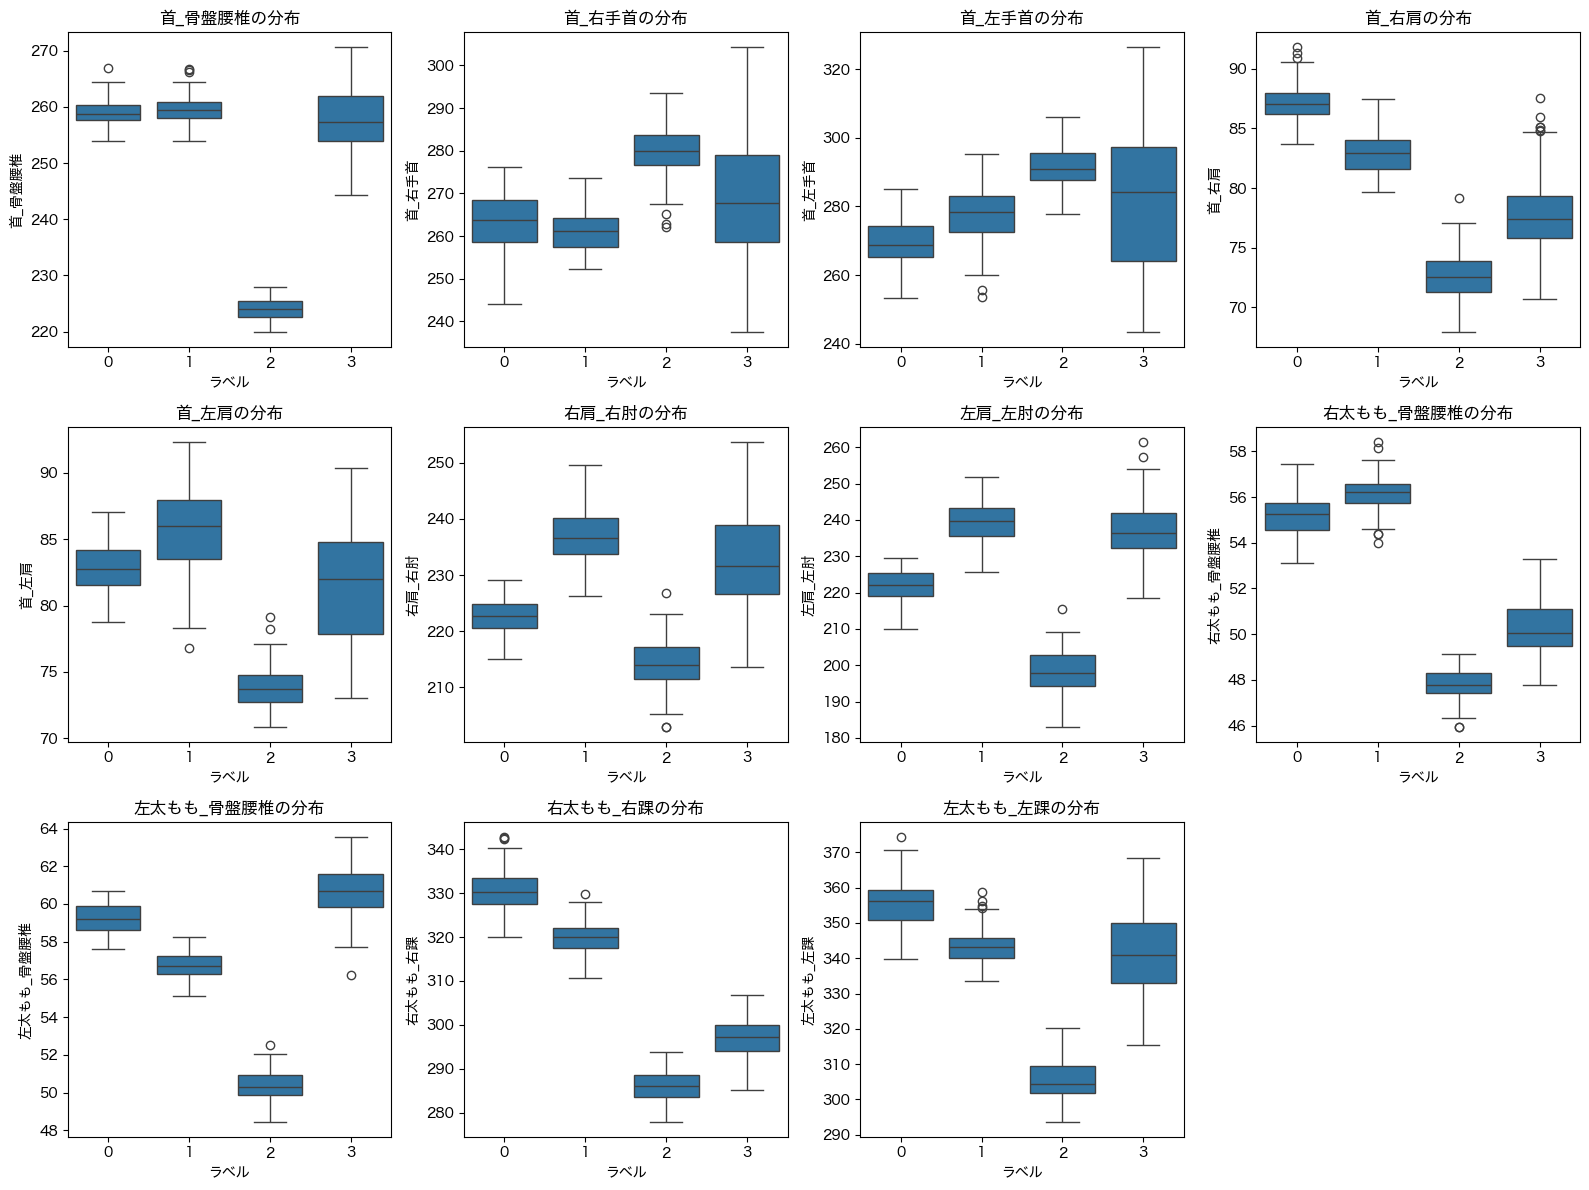

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 統計量の計算
valid_columns = ['ラベル', '首_骨盤腰椎', '首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝']
summary = data_with_distances_and_angles.loc[:, [col for col in valid_columns if col in data_with_distances_and_angles.columns]]

summary_mean = summary.groupby('ラベル').mean().T
summary_std = summary.groupby('ラベル').std().T
summary_min = summary.groupby('ラベル').min().T
summary_median = summary.groupby('ラベル').median().T
summary_max = summary.groupby('ラベル').max().T

# 統計量を統合した詳細なDataFrameを作成
def create_detailed_summary():
    stats = []
    for angle in summary_mean.columns:
        for label in summary_mean.index:
            stats.append({
                '角度': angle,
                'ラベル': label,
                '平均値': summary_mean.loc[label, angle],
                '標準偏差': summary_std.loc[label, angle],
                '最小値': summary_min.loc[label, angle],
                '中央値': summary_median.loc[label, angle],
                '最大値': summary_max.loc[label, angle]
            })
    return pd.DataFrame(stats)

detailed_summary = create_detailed_summary()

# 表形式での出力
def print_formatted_summary():
    print("=== 角度データの要約統計量 ===")
    for angle in summary_mean.columns:
        print(f"\n【{angle}】")
        angle_data = detailed_summary[detailed_summary['角度'] == angle]
        formatted_data = angle_data[['ラベル', '平均値', '標準偏差', '最小値', '中央値', '最大値']]
        print(formatted_data.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print_formatted_summary()

# 視覚化：箱ひげ図
num_plots = len(summary.columns) - 1  # 'ラベル'列を除外
num_rows = (num_plots // 4) + (1 if num_plots % 4 != 0 else 0)

plt.figure(figsize=(16, 4 * num_rows))
for i, angle in enumerate(summary.columns[1:]):  # 'ラベル'列を除外
    plt.subplot(num_rows, 4, i+1)
    sns.boxplot(x='ラベル', y=angle, data=summary)
    plt.title(f'{angle}の分布')
    plt.xticks(ticks=[0, 1, 2, 3], labels=['0', '1', '2', '3'])  # ラベルを0, 1, 2, 3に設定
    plt.tight_layout()

plt.show()

### メモ
- ラベル 0（おそらく「良い姿勢」）
首の位置（首_骨盤腰椎、首_右肩、首_左肩）
安定しており、大きなばらつきがない。
他のラベルと比べて中間の値を維持している。

腕の位置（右肩_右肘、左肘_左肩）
適度な角度を維持しており、極端な曲げや伸ばしはない。

足の位置（骨盤腰椎_右踝、骨盤腰椎_左踝）
他のラベルと比べて距離が大きめで安定している。

➡ 良い姿勢の特徴は、首・肩・腰・足がバランスよく配置されていること。

- ラベル 1（「悪い姿勢 1」）
首の位置
全体的に高めの値を示しており、頭が上がり気味。

腕の位置
右肩_右肘・左肘_左肩の値がラベル0よりも大きく、腕が開き気味。

足の位置
やや広がっているが、極端な傾向はない。

➡ 頭が上がり気味で、腕が開きすぎている傾向がある。

- ラベル 2（「悪い姿勢 2」）
首の位置
ラベル0と比べて低い。前かがみになっている可能性がある。

腕の位置
右肩_右肘・左肘_左肩の値が他のラベルよりも小さい。腕が縮こまっている。

足の位置
骨盤腰椎_右踝・骨盤腰椎_左踝が他のラベルよりも狭い。重心が前に寄っている可能性。

➡ 前かがみで、腕が縮こまっており、全体的にコンパクトな姿勢になっている。

- ラベル 3（「悪い姿勢 3」）
首の位置
最も低く、前かがみか下を向いている可能性。

腕の位置
右肩_右肘・左肘_左肩の値が大きく、腕を開きすぎている可能性。

足の位置
骨盤腰椎_右踝・骨盤腰椎_左踝の距離が最も小さい。膝を内側に寄せてしまっている可能性。

➡ 頭が下がりすぎ、腕が開きすぎ、足が内側に寄りすぎている可能性。

=== 角度データの要約統計量 ===

【右肩_左肩比率】
 ラベル  平均値  標準偏差  最小値  中央値  最大値
   0 1.05  0.03 0.96 1.05 1.13
   1 0.97  0.05 0.87 0.96 1.13
   2 0.99  0.04 0.88 0.99 1.11
   3 0.96  0.09 0.79 0.93 1.19

【右手首_左手首比率】
 ラベル  平均値  標準偏差  最小値  中央値  最大値
   0 0.98  0.03 0.89 0.98 1.04
   1 0.94  0.03 0.89 0.94 1.03
   2 0.96  0.02 0.92 0.96 0.99
   3 0.95  0.04 0.88 0.95 1.04

【右肘_左肘比率】
 ラベル  平均値  標準偏差  最小値  中央値  最大値
   0 1.00  0.02 0.96 1.00 1.05
   1 0.99  0.03 0.91 0.99 1.06
   2 1.08  0.03 1.00 1.08 1.14
   3 0.98  0.03 0.91 0.98 1.06

【右太もも_左太もも比率】
 ラベル  平均値  標準偏差  最小値  中央値  最大値
   0 0.93  0.02 0.88 0.93 1.00
   1 0.99  0.02 0.94 0.99 1.03
   2 0.95  0.02 0.89 0.95 1.00
   3 0.83  0.03 0.76 0.83 0.91

【右踝_左踝比率】
 ラベル  平均値  標準偏差  最小値  中央値  最大値
   0 0.93  0.02 0.87 0.93 0.99
   1 0.93  0.02 0.90 0.93 0.98
   2 0.94  0.02 0.89 0.94 0.99
   3 0.87  0.03 0.80 0.87 0.95


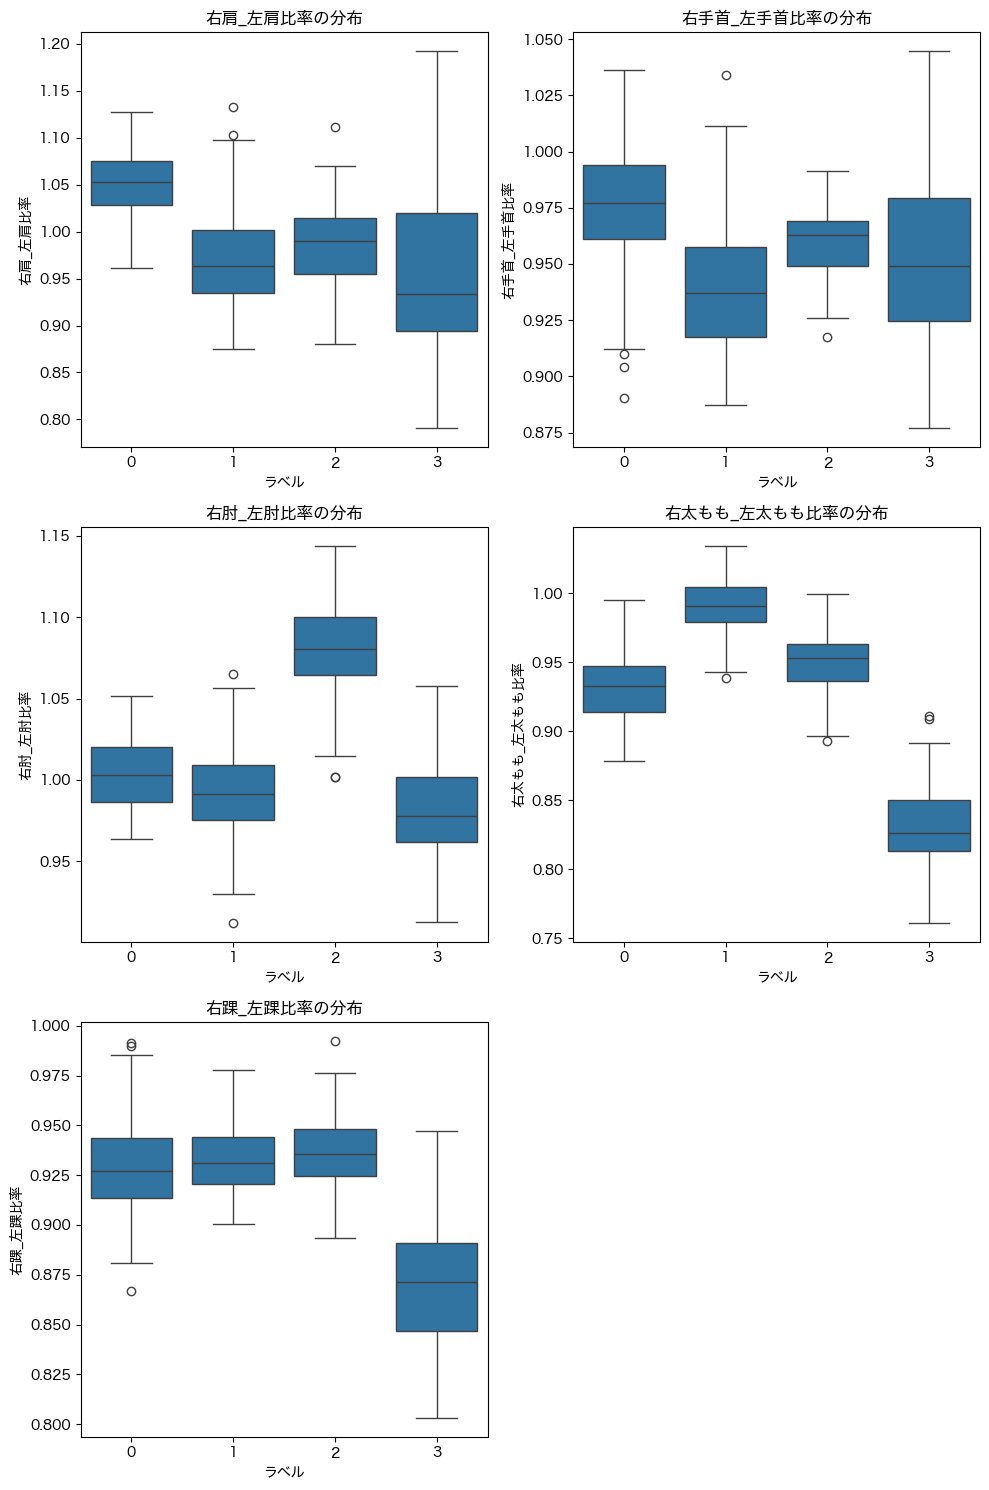

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 統計量の計算
valid_columns = ['ラベル', '首_骨盤腰椎', '首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝']
summary = data_with_distances_and_angles.loc[:, [col for col in valid_columns if col in data_with_distances_and_angles.columns]]

# 左右対称性の比率を計算
summary['右肩_左肩比率'] = summary['首_右肩'] / summary['首_左肩']
summary['右手首_左手首比率'] = summary['首_右手首'] / summary['首_左手首']
summary['右肘_左肘比率'] = summary['右肩_右肘'] / summary['左肩_左肘']
summary['右太もも_左太もも比率'] = summary['右太もも_骨盤腰椎'] / summary['左太もも_骨盤腰椎']
summary['右踝_左踝比率'] = summary['右太もも_右踝'] / summary['左太もも_左踝']

# 左右差と比率のみを保持
summary_filtered = summary[['ラベル', '右肩_左肩比率', '右手首_左手首比率', '右肘_左肘比率','右太もも_左太もも比率','右踝_左踝比率']]

# 比率を追加した後の統計量計算
summary_mean = summary_filtered.groupby('ラベル').mean().T
summary_std = summary_filtered.groupby('ラベル').std().T
summary_min = summary_filtered.groupby('ラベル').min().T
summary_median = summary_filtered.groupby('ラベル').median().T
summary_max = summary_filtered.groupby('ラベル').max().T

# 統計量を統合した詳細なDataFrameを作成
def create_detailed_summary():
    stats = []
    for label in summary_mean.index:
        for angle in summary_mean.columns:
            stats.append({
                '角度': label,
                'ラベル': angle,
                '平均値': summary_mean.loc[label, angle],
                '標準偏差': summary_std.loc[label, angle],
                '最小値': summary_min.loc[label, angle],
                '中央値': summary_median.loc[label, angle],
                '最大値': summary_max.loc[label, angle]
            })
    return pd.DataFrame(stats)

detailed_summary = create_detailed_summary()

# 表形式での出力
def print_formatted_summary():
    print("=== 角度データの要約統計量 ===")
    for angle in summary_mean.index:
        print(f"\n【{angle}】")
        angle_data = detailed_summary[detailed_summary['角度'] == angle]
        formatted_data = angle_data[['ラベル', '平均値', '標準偏差', '最小値', '中央値', '最大値']]
        print(formatted_data.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print_formatted_summary()
# 視覚化：箱ひげ図（summary_filteredを使用）
# summary_filteredデータフレームの列数を決定
num_columns = len([c for c in ['右肩_左肩比率', '右手首_左手首比率', '右肘_左肘比率','右太もも_左太もも比率','右踝_左踝比率']])
num_rows = (num_columns + 1) // 2  # 2列のグリッドにするため行数を計算

plt.figure(figsize=(10, 5 * num_rows))  # サイズを調整

# 各比率に対してboxplotを作成
for i, col in enumerate(['右肩_左肩比率', '右手首_左手首比率', '右肘_左肘比率','右太もも_左太もも比率','右踝_左踝比率']):
    plt.subplot(num_rows, 2, i + 1)  # 2列に並べる
    sns.boxplot(x='ラベル', y=col, data=summary_filtered)
    plt.title(f'{col}の分布', fontsize=12)

plt.tight_layout()  # レイアウト調整
plt.show()

## LightGBMによる分類〜骨格間の距離座標〜

訓練セットの件数: 282
テストセットの件数: 121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1045
[LightGBM] [Info] Number of data points in the train set: 282, number of used features: 11
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Info] Start training from score -1.393412
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	train's multi_logloss: 0.00112514	valid's multi_logloss: 0.00426417
Accuracy: 1.0000


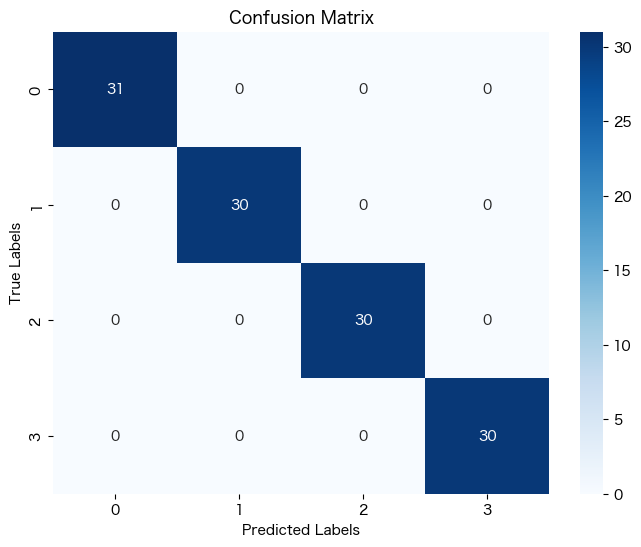

Accuracy: 1.0000
Precision (Weighted): 1.0000
Recall (Weighted): 1.0000
F1 Score (Weighted): 1.0000


<Figure size 1000x800 with 0 Axes>

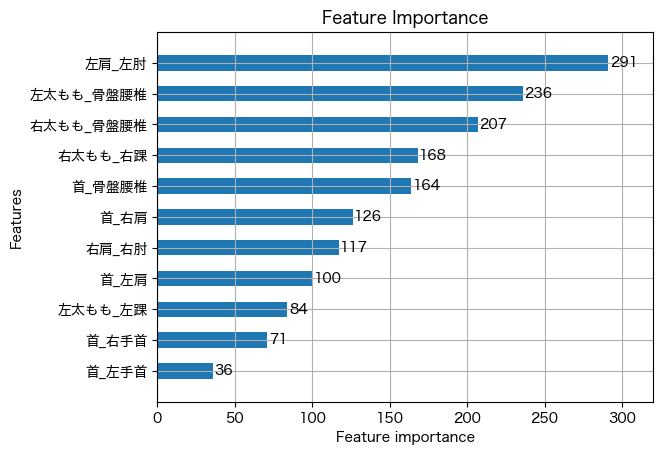

In [24]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from matplotlib import rcParams
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# データ確認
# ラベルを数値型に変換
angle_skeleton = data_with_distances_and_angles.drop_duplicates(subset='画像情報')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(angle_skeleton["ラベル"])

# 特徴量とターゲットの格納
X = angle_skeleton.loc[:, ['首_骨盤腰椎', '首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝']]

# データを訓練セットとテストセットに分割（クラス分布を維持）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)
# 訓練セットとテストセットの件数を表示
print("訓練セットの件数:", X_train.shape[0])
print("テストセットの件数:", X_test.shape[0])

# クラス数の取得
num_classes = len(np.unique(y))  # クラス数を計算

# LightGBMのデータ形式に変換
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test, reference=dtrain)

# モデルの学習
params = {
    "objective": "multiclass",  # 多クラス分類
    "metric": "multi_logloss",  # 多クラス分類の評価指標
    "boosting_type": "gbdt",
    "num_leaves": 5,  # 1つの決定木で使用される葉の数（複雑さ）を指定
    "learning_rate": 0.05, # 学習率(1回の学習で重みをどれだけ更新するかを指定)
    "feature_fraction": 0.7, # 各学習イテレーションで使用される特徴量の割合を指定
    "min_data_in_leaf": 20,  # 各葉に含まれる最低データ数を指定
    "early_stopping_rounds": 10,  # early stoppingをparamsに設定
    "num_class": num_classes,  # クラス数を指定
}

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dvalid],        # 訓練データと検証データ
    valid_names=['train', 'valid'],     # データセットの名前を指定
    num_boost_round=100,
)

# テストデータで予測
pred_probs = model.predict(X_test, num_iteration=model.best_iteration)
pred_classes = np.argmax(pred_probs, axis=1)  # 確率をクラスに変換

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# 混同行列の作成
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# 混同行列の作成
conf_matrix = confusion_matrix(y_test, pred_classes)

# 混同行列をヒートマップで表示
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1 Score
precision = precision_score(y_test, pred_classes, average='weighted')
recall = recall_score(y_test, pred_classes, average='weighted')
f1 = f1_score(y_test, pred_classes, average='weighted')

print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1 Score (Weighted): {f1:.4f}")

# 特徴量の重要度を可視化
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, height=0.5, max_num_features=20)
plt.title("Feature Importance")
plt.show()

#### メモ
- 正解率（Accuracy）：全体の中での正解率
- 適合率（Precision）：正解と予測したデータのうち、実際に正解である確率
- 再現率（Recall）：実際に正解であるデータのうち、正解と予測した確率
- F1スコア：適合率と再現率に対して調和平均を表したもの

## LightGBMによる分類〜角度〜

In [25]:
# カラム確認
data_with_distances_and_angles.columns

Index(['画像情報', 'ラベル', '首_骨盤腰椎', '首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝', '首の角度',
       '右肘の角度', '左肘の角度', '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度'],
      dtype='object')

訓練セットの件数: 282
テストセットの件数: 121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 282, number of used features: 7
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best 

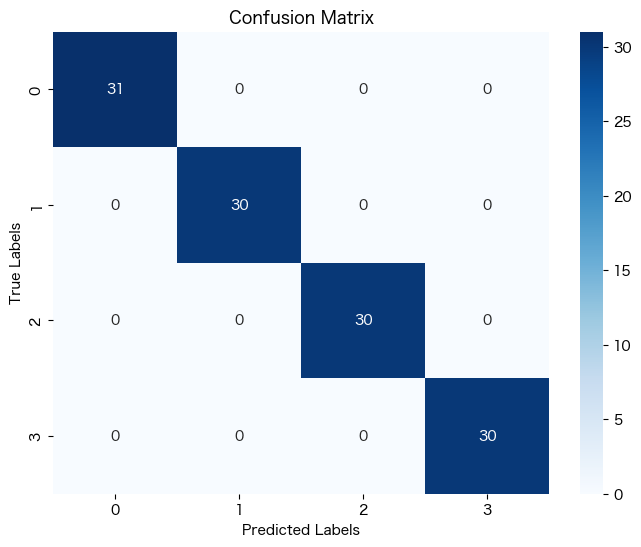

Accuracy: 1.0000
Precision (Weighted): 1.0000
Recall (Weighted): 1.0000
F1 Score (Weighted): 1.0000


<Figure size 1000x800 with 0 Axes>

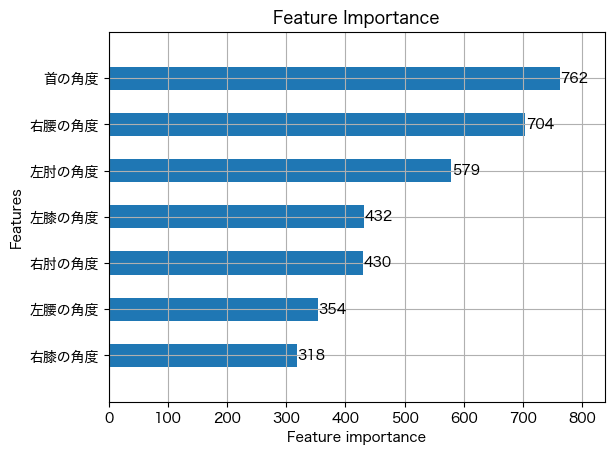

In [26]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from matplotlib import rcParams
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# データ確認
# ラベルを数値型に変換
angle_skeleton = data_with_distances_and_angles.drop_duplicates(subset='画像情報')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(angle_skeleton["ラベル"])

# 特徴量とターゲットの格納
X = angle_skeleton.loc[:, ['首の角度', '右肘の角度', '左肘の角度',
                        '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度']]

# データを訓練セットとテストセットに分割（クラス分布を維持）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)
# 訓練セットとテストセットの件数を表示
print("訓練セットの件数:", X_train.shape[0])
print("テストセットの件数:", X_test.shape[0])

# クラス数の取得
num_classes = len(np.unique(y))  # クラス数を計算

# LightGBMのデータ形式に変換
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test, reference=dtrain)

# モデルの学習
params = {
    "objective": "multiclass",  # 多クラス分類
    "metric": "multi_logloss",  # 多クラス分類の評価指標
    "boosting_type": "gbdt",
    "num_leaves": 10,  # 1つの決定木で使用される葉の数（複雑さ）を指定
    "learning_rate": 0.05, # 学習率(1回の学習で重みをどれだけ更新するかを指定)
    "feature_fraction": 0.7, # 各学習イテレーションで使用される特徴量の割合を指定
    "min_data_in_leaf": 20,  # 各葉に含まれる最低データ数を指定
    "early_stopping_rounds": 10,  # early stoppingをparamsに設定
    "num_class": num_classes,  # クラス数を指定
}

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dvalid],        # 訓練データと検証データ
    valid_names=['train', 'valid'],     # データセットの名前を指定
    num_boost_round=100,
)

# テストデータで予測
pred_probs = model.predict(X_test, num_iteration=model.best_iteration)
pred_classes = np.argmax(pred_probs, axis=1)  # 確率をクラスに変換

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# 混同行列の作成
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# 混同行列の作成
conf_matrix = confusion_matrix(y_test, pred_classes)

# 混同行列をヒートマップで表示
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1 Score
precision = precision_score(y_test, pred_classes, average='weighted')
recall = recall_score(y_test, pred_classes, average='weighted')
f1 = f1_score(y_test, pred_classes, average='weighted')

print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1 Score (Weighted): {f1:.4f}")

# 特徴量の重要度を可視化
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, height=0.5, max_num_features=20)
plt.title("Feature Importance")
plt.show()

## LightGBMによる分類〜角度と距離〜

In [ ]:
# カラム確認
data_with_distances_and_angles.columns

訓練セットの件数: 282
テストセットの件数: 121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1710
[LightGBM] [Info] Number of data points in the train set: 282, number of used features: 18
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration

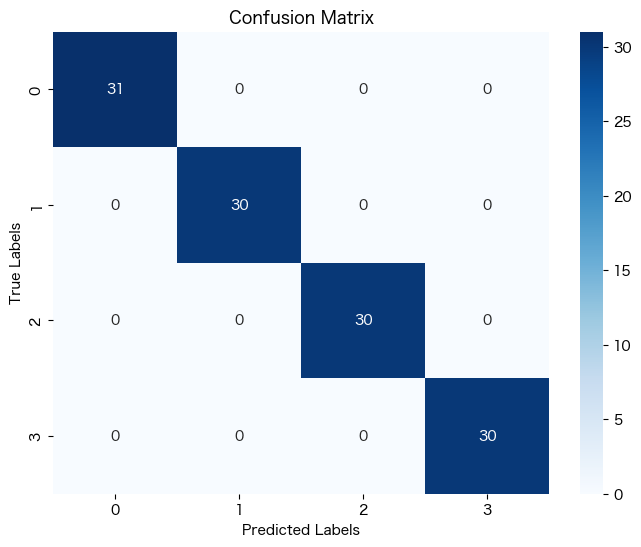

Accuracy: 1.0000
Precision (Weighted): 1.0000
Recall (Weighted): 1.0000
F1 Score (Weighted): 1.0000


<Figure size 1000x800 with 0 Axes>

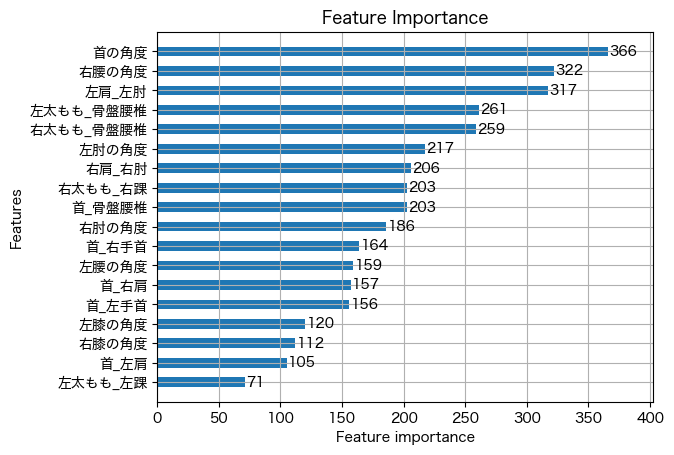

In [10]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from matplotlib import rcParams
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# データ確認
# ラベルを数値型に変換
distance_skeleton = data_with_distances_and_angles.drop_duplicates(subset='画像情報')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(distance_skeleton["ラベル"])

# 特徴量とターゲットの格納
X = distance_skeleton.loc[:, ['首_骨盤腰椎', '首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝', '首の角度',
       '右肘の角度', '左肘の角度', '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度']]

# データを訓練セットとテストセットに分割（クラス分布を維持）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)
# 訓練セットとテストセットの件数を表示
print("訓練セットの件数:", X_train.shape[0])
print("テストセットの件数:", X_test.shape[0])

# クラス数の取得
num_classes = len(np.unique(y))  # クラス数を計算

# LightGBMのデータ形式に変換
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test, reference=dtrain)

# モデルの学習
params = {
    "objective": "multiclass",  # 多クラス分類
    "metric": "multi_logloss",  # 多クラス分類の評価指標
    "boosting_type": "gbdt",
    "num_leaves": 10,  # 1つの決定木で使用される葉の数（複雑さ）を指定
    "learning_rate": 0.05, # 学習率(1回の学習で重みをどれだけ更新するかを指定)
    "feature_fraction": 0.7, # 各学習イテレーションで使用される特徴量の割合を指定
    "min_data_in_leaf": 10,  # 各葉に含まれる最低データ数を指定
    "early_stopping_rounds": 10,  # early stoppingをparamsに設定
    "num_class": num_classes,  # クラス数を指定
}

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dvalid],        # 訓練データと検証データ
    valid_names=['train', 'valid'],     # データセットの名前を指定
    num_boost_round=100,
)

# テストデータで予測
pred_probs = model.predict(X_test, num_iteration=model.best_iteration)
pred_classes = np.argmax(pred_probs, axis=1)  # 確率をクラスに変換

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# 混同行列の作成
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# 混同行列の作成
conf_matrix = confusion_matrix(y_test, pred_classes)

# 混同行列をヒートマップで表示
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1 Score
precision = precision_score(y_test, pred_classes, average='weighted')
recall = recall_score(y_test, pred_classes, average='weighted')
f1 = f1_score(y_test, pred_classes, average='weighted')

print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1 Score (Weighted): {f1:.4f}")

# 特徴量の重要度を可視化
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, height=0.5, max_num_features=20)
plt.title("Feature Importance")
plt.show()

## LightGBMによる分類 ~対称性~

訓練セットの件数: 282
テストセットの件数: 121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 950
[LightGBM] [Info] Number of data points in the train set: 282, number of used features: 10
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	train's multi_logloss: 0.000924878	valid's multi_loglo

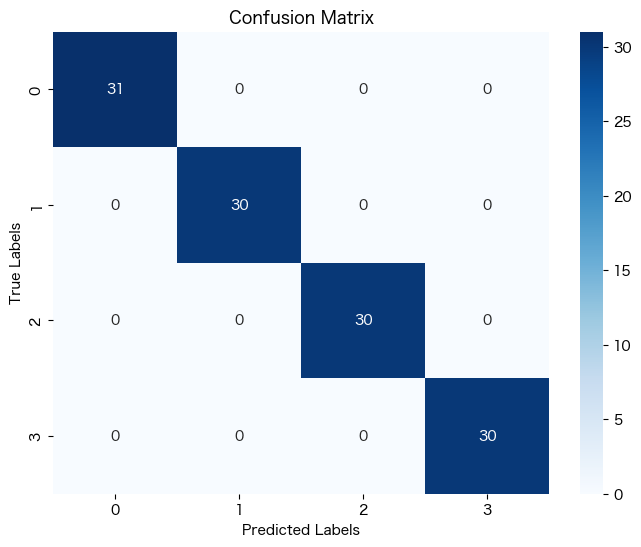

Precision (Weighted): 1.0000
Recall (Weighted): 1.0000
F1 Score (Weighted): 1.0000


<Figure size 1000x800 with 0 Axes>

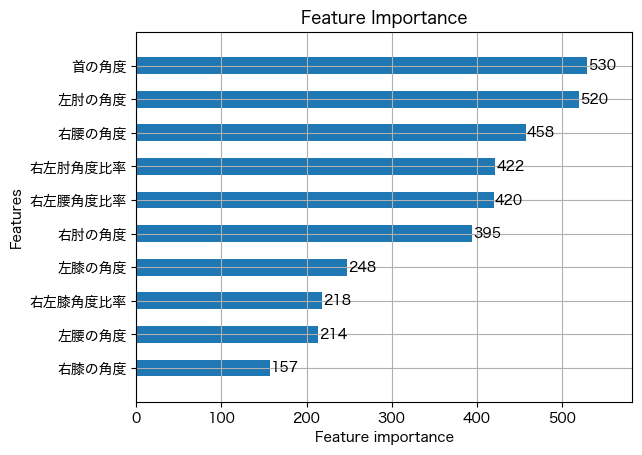

In [30]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

# データ確認
# ラベルを数値型に変換
angle_skeleton = data_with_distances_and_angles.drop_duplicates(subset='画像情報')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(angle_skeleton["ラベル"])

# 特徴量とターゲットの格納
X = angle_skeleton.loc[:, ['首の角度', '右肘の角度', '左肘の角度',
                            '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度']]

# 左右対称性を加味した特徴量の作成
X['右左肘角度差'] = X['右肘の角度'] - X['左肘の角度']
X['右左肘角度平均'] = (X['右肘の角度'] + X['左肘の角度']) / 2
X['右左肘角度比率'] = X['右肘の角度'] / (X['左肘の角度'] + 1e-6)

X['右左膝角度差'] = X['右膝の角度'] - X['左膝の角度']
X['右左膝角度平均'] = (X['右膝の角度'] + X['左膝の角度']) / 2
X['右左膝角度比率'] = X['右膝の角度'] / (X['左膝の角度'] + 1e-6)

X['右左腰角度差'] = X['右腰の角度'] - X['左腰の角度']
X['右左腰角度平均'] = (X['右腰の角度'] + X['左腰の角度']) / 2
X['右左腰角度比率'] = X['右腰の角度'] / (X['左腰の角度'] + 1e-6)

# 特徴量とターゲットの再格納
X = X[['首の角度', '右肘の角度', '左肘の角度',
        '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度','右左肘角度比率','右左膝角度比率', '右左腰角度比率']]

# データを訓練セットとテストセットに分割（クラス分布を維持）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)

# 訓練セットとテストセットの件数を表示
print("訓練セットの件数:", X_train.shape[0])
print("テストセットの件数:", X_test.shape[0])

# クラス数の取得
num_classes = len(np.unique(y))  # クラス数を計算

# LightGBMのデータ形式に変換
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test, reference=dtrain)

# モデルの学習
params = {
    "objective": "multiclass",  # 多クラス分類
    "metric": "multi_logloss",  # 多クラス分類の評価指標
    "boosting_type": "gbdt",
    "num_leaves": 10,  # 1つの決定木で使用される葉の数（複雑さ）を指定
    "learning_rate": 0.05,  # 学習率(1回の学習で重みをどれだけ更新するかを指定)
    "feature_fraction": 0.7,  # 各学習イテレーションで使用される特徴量の割合を指定
    "min_data_in_leaf": 20,  # 各葉に含まれる最低データ数を指定
    "early_stopping_rounds": 10,  # early stoppingをparamsに設定
    "num_class": num_classes,  # クラス数を指定
}

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dvalid],        # 訓練データと検証データ
    valid_names=['train', 'valid'],     # データセットの名前を指定
    num_boost_round=100,
)

# テストデータで予測
pred_probs = model.predict(X_test, num_iteration=model.best_iteration)
pred_classes = np.argmax(pred_probs, axis=1)  # 確率をクラスに変換

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# 混同行列の作成
conf_matrix = confusion_matrix(y_test, pred_classes)

# 混同行列をヒートマップで表示
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Precision, Recall, F1 Score
precision = precision_score(y_test, pred_classes, average='weighted')
recall = recall_score(y_test, pred_classes, average='weighted')
f1 = f1_score(y_test, pred_classes, average='weighted')

print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1 Score (Weighted): {f1:.4f}")

# 特徴量の重要度を可視化
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, height=0.5, max_num_features=20)
plt.title("Feature Importance")
plt.show()


訓練セットの件数: 282
テストセットの件数: 121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1425
[LightGBM] [Info] Number of data points in the train set: 282, number of used features: 15
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	train's multi_logloss: 0.00105523	valid's multi_logloss: 0.0187589
Accuracy: 0.9917


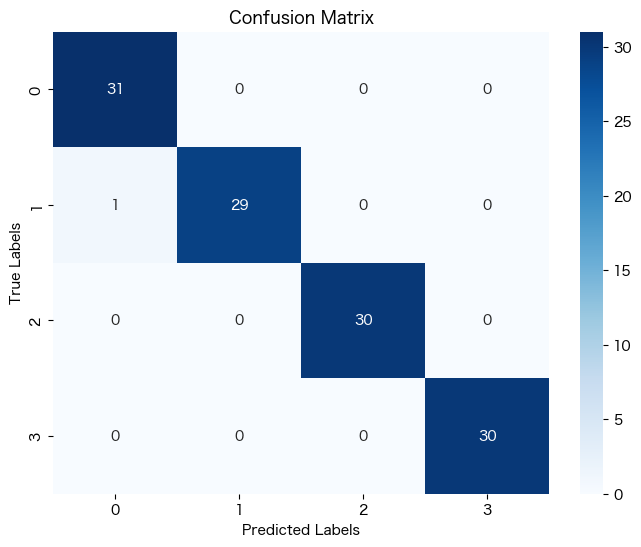

Accuracy: 0.9917
Precision (Weighted): 0.9920
Recall (Weighted): 0.9917
F1 Score (Weighted): 0.9917


<Figure size 1000x800 with 0 Axes>

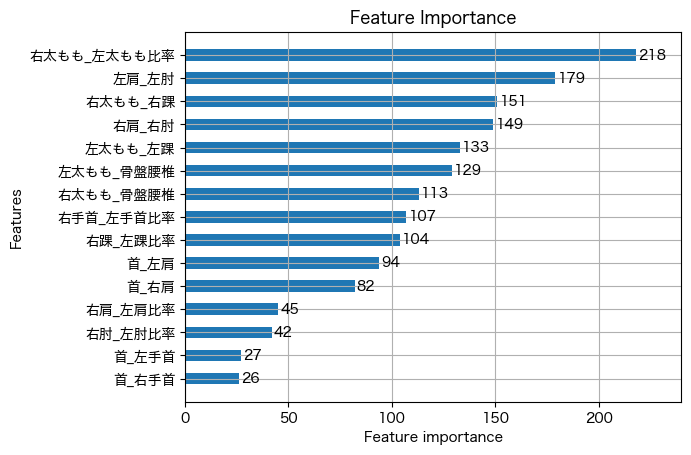

In [31]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# ラベルを数値型に変換
angle_skeleton = data_with_distances_and_angles.drop_duplicates(subset='画像情報')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(angle_skeleton["ラベル"])

# 特徴量をsummary_filteredから抽出（骨格の比率を使用）
X = angle_skeleton.loc[:, ['首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝']]

# 左右対称性の比率を計算
X['右肩_左肩比率'] = X['首_右肩'] / (X['首_左肩'] + 1e-6)
X['右手首_左手首比率'] = X['首_右手首'] / (X['首_左手首'] + 1e-6)
X['右肘_左肘比率'] = X['右肩_右肘'] / (X['左肩_左肘'] + 1e-6)
X['右太もも_左太もも比率'] = X['右太もも_骨盤腰椎'] / (summary['左太もも_骨盤腰椎'] + 1e-6)
X['右踝_左踝比率'] = X['右太もも_右踝'] / (X['左太もも_左踝'] + 1e-6)

# 特徴量とターゲットの再格納
X = X[['首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝'
      ,'右肩_左肩比率','右手首_左手首比率','右肘_左肘比率','右太もも_左太もも比率','右踝_左踝比率']]

# データを訓練セットとテストセットに分割（クラス分布を維持）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)
# 訓練セットとテストセットの件数を表示
print("訓練セットの件数:", X_train.shape[0])
print("テストセットの件数:", X_test.shape[0])

# クラス数の取得
num_classes = len(np.unique(y))  # クラス数を計算

# LightGBMのデータ形式に変換
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test, reference=dtrain)

# モデルの学習
params = {
    "objective": "multiclass",  # 多クラス分類
    "metric": "multi_logloss",  # 多クラス分類の評価指標
    "boosting_type": "gbdt",
    "num_leaves": 5,  # 1つの決定木で使用される葉の数（複雑さ）を指定
    "learning_rate": 0.05, # 学習率(1回の学習で重みをどれだけ更新するかを指定)
    "feature_fraction": 0.7, # 各学習イテレーションで使用される特徴量の割合を指定
    "min_data_in_leaf": 20,  # 各葉に含まれる最低データ数を指定
    "early_stopping_rounds": 10,  # early stoppingをparamsに設定
    "num_class": num_classes,  # クラス数を指定
}

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dvalid],        # 訓練データと検証データ
    valid_names=['train', 'valid'],     # データセットの名前を指定
    num_boost_round=100,
)

# テストデータで予測
pred_probs = model.predict(X_test, num_iteration=model.best_iteration)
pred_classes = np.argmax(pred_probs, axis=1)  # 確率をクラスに変換

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# 混同行列の作成
conf_matrix = confusion_matrix(y_test, pred_classes)

# 混同行列をヒートマップで表示
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1 Score
precision = precision_score(y_test, pred_classes, average='weighted')
recall = recall_score(y_test, pred_classes, average='weighted')
f1 = f1_score(y_test, pred_classes, average='weighted')

print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1 Score (Weighted): {f1:.4f}")

# 特徴量の重要度を可視化
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, height=0.5, max_num_features=20)
plt.title("Feature Importance")
plt.show()

訓練セットの件数: 282
テストセットの件数: 121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 282, number of used features: 25
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.379227
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Info] Start training from score -1.393412
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	train's multi_logloss: 0.00092594	valid's multi_loglo

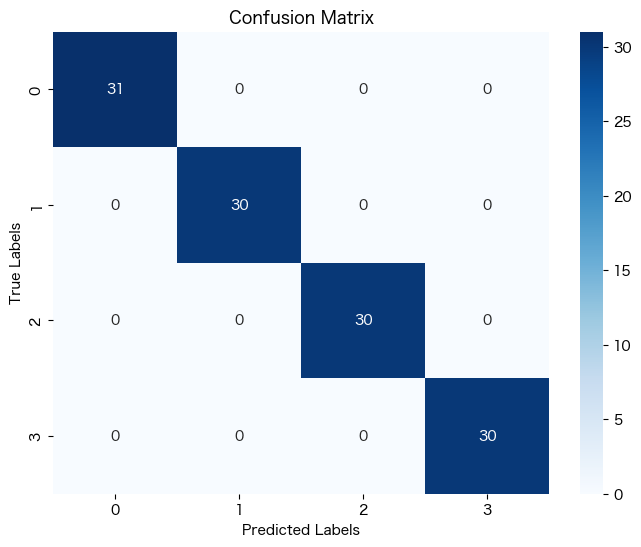

Accuracy: 1.0000
Precision (Weighted): 1.0000
Recall (Weighted): 1.0000
F1 Score (Weighted): 1.0000


<Figure size 1000x800 with 0 Axes>

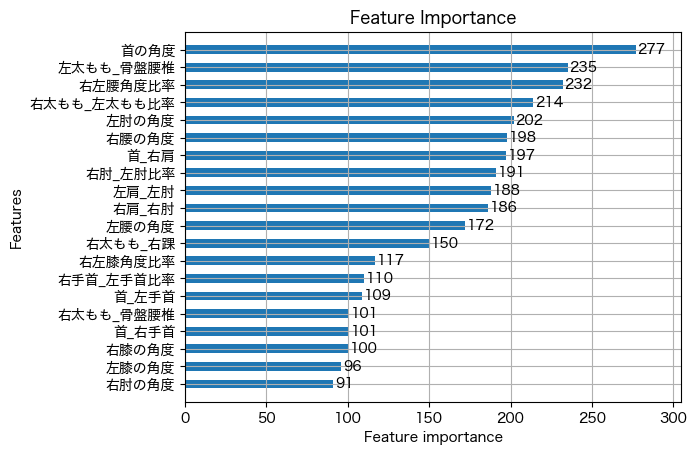

In [13]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# ラベルを数値型に変換
angle_skeleton = data_with_distances_and_angles.drop_duplicates(subset='画像情報')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(angle_skeleton["ラベル"])
# 特徴量とターゲットの格納
X = angle_skeleton.loc[:, ['首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝', '首の角度',
       '右肘の角度', '左肘の角度', '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度']]

# 特徴量をsummary_filteredから抽出（骨格の比率を使用）
# 角度左右対称性を加味した特徴量の作成
X['右左肘角度差'] = X['右肘の角度'] - X['左肘の角度']
X['右左肘角度平均'] = (X['右肘の角度'] + X['左肘の角度']) / 2
X['右左肘角度比率'] = X['右肘の角度'] / (X['左肘の角度'] + 1e-6)

X['右左膝角度差'] = X['右膝の角度'] - X['左膝の角度']
X['右左膝角度平均'] = (X['右膝の角度'] + X['左膝の角度']) / 2
X['右左膝角度比率'] = X['右膝の角度'] / (X['左膝の角度'] + 1e-6)

X['右左腰角度差'] = X['右腰の角度'] - X['左腰の角度']
X['右左腰角度平均'] = (X['右腰の角度'] + X['左腰の角度']) / 2
X['右左腰角度比率'] = X['右腰の角度'] / (X['左腰の角度'] + 1e-6)

# 距離
# 左右対称性の比率を計算
X['右肩_左肩比率'] = X['首_右肩'] / (X['首_左肩'] + 1e-6)
X['右手首_左手首比率'] = X['首_右手首'] / (X['首_左手首'] + 1e-6)
X['右肘_左肘比率'] = X['右肩_右肘'] / (X['左肩_左肘'] + 1e-6)
X['右太もも_左太もも比率'] = X['右太もも_骨盤腰椎'] / (X['左太もも_骨盤腰椎'] + 1e-6)
X['右踝_左踝比率'] = X['右太もも_右踝'] / (X['左太もも_左踝'] + 1e-6)

# 特徴量とターゲットの再格納
X = X[['首_右手首', '首_左手首', '首_右肩', '首_左肩', '右肩_右肘',
       '左肩_左肘', '右太もも_骨盤腰椎', '左太もも_骨盤腰椎', '右太もも_右踝', '左太もも_左踝', '首の角度',
       '右肘の角度', '左肘の角度', '右膝の角度', '左膝の角度', '右腰の角度', '左腰の角度','右左肘角度比率','右左膝角度比率', '右左腰角度比率','右肩_左肩比率','右手首_左手首比率','右肘_左肘比率','右太もも_左太もも比率','右踝_左踝比率']]

# データを訓練セットとテストセットに分割（クラス分布を維持）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)
# 訓練セットとテストセットの件数を表示
print("訓練セットの件数:", X_train.shape[0])
print("テストセットの件数:", X_test.shape[0])

# クラス数の取得
num_classes = len(np.unique(y))  # クラス数を計算

# LightGBMのデータ形式に変換
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test, reference=dtrain)

# モデルの学習
params = {
    "objective": "multiclass",  # 多クラス分類
    "metric": "multi_logloss",  # 多クラス分類の評価指標
    "boosting_type": "gbdt",
    "num_leaves": 10,  # 1つの決定木で使用される葉の数（複雑さ）を指定
    "learning_rate": 0.05, # 学習率(1回の学習で重みをどれだけ更新するかを指定)
    "feature_fraction": 0.7, # 各学習イテレーションで使用される特徴量の割合を指定
    "min_data_in_leaf": 20,  # 各葉に含まれる最低データ数を指定
    "early_stopping_rounds": 10,  # early stoppingをparamsに設定
    "num_class": num_classes,  # クラス数を指定
}

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dvalid],        # 訓練データと検証データ
    valid_names=['train', 'valid'],     # データセットの名前を指定
    num_boost_round=100,
)

# テストデータで予測
pred_probs = model.predict(X_test, num_iteration=model.best_iteration)
pred_classes = np.argmax(pred_probs, axis=1)  # 確率をクラスに変換

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# 混同行列の作成
conf_matrix = confusion_matrix(y_test, pred_classes)

# 混同行列をヒートマップで表示
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# 精度評価
accuracy = accuracy_score(y_test, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1 Score
precision = precision_score(y_test, pred_classes, average='weighted')
recall = recall_score(y_test, pred_classes, average='weighted')
f1 = f1_score(y_test, pred_classes, average='weighted')

print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1 Score (Weighted): {f1:.4f}")

# 特徴量の重要度を可視化
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, height=0.5, max_num_features=20)
plt.title("Feature Importance")
plt.show()